# Risk Screening Under Limited Review Capacity


##Project Outline



### 1. Problem Definition
### 2. Data Loading and Sanity Checks
### 3. Temporal Setup and Review Windows
### 4. Review Capacity Constraint
### 5. Baseline Policies
### 6. Probabilistic Modeling
### 7. Decision Policy Evaluation
### 8. Stress Testing and Sensitivity Analysis
### 9. Conclusions and Limitations

## 1. Problem Definition

### 1.1 Business Context

Financial institutions process a very large volume of transactions in real time. A small fraction of these transactions are fraudulent, but investigating fraud is costly and requires manual review by specialized teams.

Because review resources are limited, it is typically infeasible to investigate all transactions flagged as suspicious. Instead, institutions must decide which transactions to review in order to minimize fraud-related losses while respecting operational constraints.

This creates a fundamental trade-off between:
- reviewing too few transactions and missing fraud, and
- reviewing too many transactions and incurring unnecessary investigation costs.

---

### 1.2 Decision Problem

At regular time intervals, a fixed number of transactions can be manually reviewed. The core decision problem is:

> **Which transactions should be selected for review, given limited review capacity, in order to maximize fraud detection and minimize expected cost?**

Importantly, this is not a pure classification problem. The objective is not to label every transaction correctly, but to prioritize a small subset of transactions for review under capacity constraints.

---

### 1.3 Modeling Objective

The goal of this project is to design and evaluate decision policies that:

- Rank transactions by fraud risk using probabilistic models
- Respect a strict per-window review capacity
- Maximize the fraction of fraud captured within reviewed transactions
- Minimize expected cost under asymmetric misclassification costs

To achieve this, the project compares naive heuristic policies with a probabilistic risk scoring approach and evaluates performance under varying operational and economic conditions.

---

### 1.4 Scope and Assumptions

This project makes the following simplifying assumptions:

- Fraud labels are observed without delay.
- Review capacity is fixed within each time window.
- Transaction features are static and anonymized.
- The system operates in discrete time windows.

These assumptions are made to isolate the core decision-making challenge rather than model full production complexity.

---

### 1.5 Evaluation Philosophy

Model performance is evaluated based on **decision outcomes**, not traditional classification metrics. The primary focus is on fraud capture under constrained review capacity, with stress testing used to assess robustness across different operating regimes.

This framing ensures that model improvements translate directly into better operational decisions.

## 2. Data Loading and Sanity Checks

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

path = "/content/drive/MyDrive/Fraud_Project/creditcard.csv"
df = pd.read_csv(path)

In [5]:
df.shape
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.isna().sum()
df['Class'].value_counts()
df['Class'].mean()

np.float64(0.001727485630620034)

## 3. Temporal Setup and Review Windows

In [7]:
assert 'Time' in df.columns, "Column 'Time' not found"
assert 'Class' in df.columns, "Column 'Class' not found"

df = df.sort_values('Time').reset_index(drop=True)

WINDOW_SIZE_SEC = 3600  # 1 hour


df['window_id'] = (df['Time'] // WINDOW_SIZE_SEC).astype(int)
df[['Time', 'window_id', 'Class']].head()


,Time,window_id,Class
0,0.0,0,0
1,0.0,0,0
2,1.0,0,0
3,1.0,0,0
4,2.0,0,0


In [8]:
window_stats = (
    df.groupby('window_id')['Class']
      .agg(transactions='count', frauds='sum', fraud_rate='mean')
      .reset_index()
)

window_stats.head()


,window_id,transactions,frauds,fraud_rate
0,0,3963,2,0.000505
1,1,2217,2,0.000902
2,2,1576,21,0.013325
3,3,1821,13,0.007139
4,4,1082,6,0.005545


In [9]:
n_windows = window_stats['window_id'].nunique()
avg_tx_per_window = window_stats['transactions'].mean()
median_tx_per_window = window_stats['transactions'].median()
avg_frauds_per_window = window_stats['frauds'].mean()
median_frauds_per_window = window_stats['frauds'].median()

print(f"WINDOW_SIZE_SEC: {WINDOW_SIZE_SEC} seconds")
print(f"Number of windows: {n_windows}")
print(f"Avg transactions per window: {avg_tx_per_window:.2f} (median {median_tx_per_window:.0f})")
print(f"Avg frauds per window: {avg_frauds_per_window:.4f} (median {median_frauds_per_window:.0f})")
print(f"Overall fraud rate: {df['Class'].mean():.6f}")

WINDOW_SIZE_SEC: 3600 seconds
Number of windows: 48
Avg transactions per window: 5933.48 (median 7710)
Avg frauds per window: 10.2500 (median 8)
Overall fraud rate: 0.001727


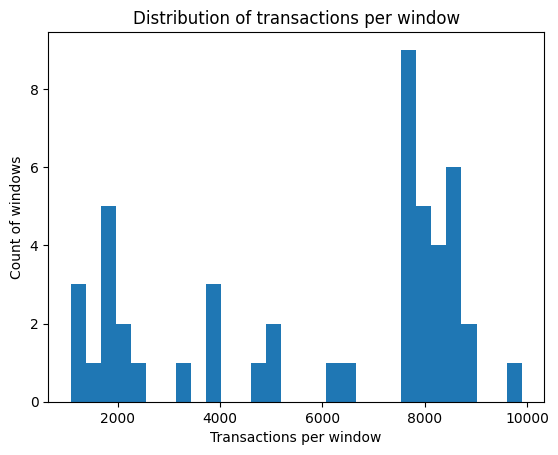

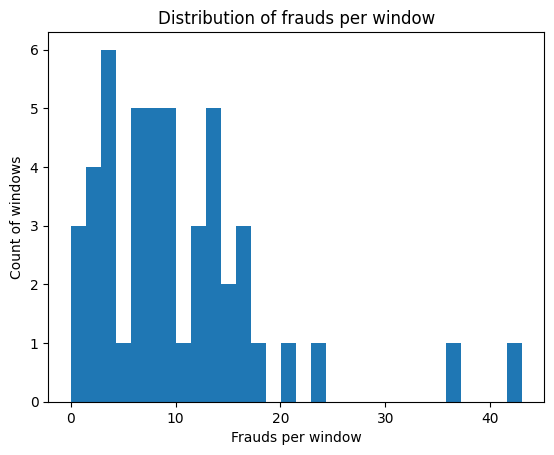

In [10]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(window_stats['transactions'], bins=30)
plt.xlabel("Transactions per window")
plt.ylabel("Count of windows")
plt.title("Distribution of transactions per window")
plt.show()

plt.figure()
plt.hist(window_stats['frauds'], bins=30)
plt.xlabel("Frauds per window")
plt.ylabel("Count of windows")
plt.title("Distribution of frauds per window")
plt.show()

## 4. Review Capacity Constraint

We assume a limited manual review capacity equal to 0.5% of incoming transactions per hour, reflecting operational constraints and forcing prioritization under uncertainty.

In [11]:
# Review capacity as a percentage of transactions per window
REVIEW_RATE = 0.005  # 0.5%

window_stats['review_capacity'] = (
    window_stats['transactions'] * REVIEW_RATE
).astype(int)

# Ensure at least 1 review per window
window_stats['review_capacity'] = window_stats['review_capacity'].clip(lower=1)

window_stats[['window_id', 'transactions', 'frauds', 'review_capacity']].head()


,window_id,transactions,frauds,review_capacity
0,0,3963,2,19
1,1,2217,2,11
2,2,1576,21,7
3,3,1821,13,9
4,4,1082,6,5


In [12]:
print(f"Review rate: {REVIEW_RATE*100:.2f}%")
print(f"Avg reviews per window: {window_stats['review_capacity'].mean():.1f}")
print(f"Median reviews per window: {window_stats['review_capacity'].median():.0f}")
print(f"Avg frauds per window: {window_stats['frauds'].mean():.1f}")

Review rate: 0.50%
Avg reviews per window: 29.2
Median reviews per window: 38
Avg frauds per window: 10.2


## 5. Baseline Policies

Policy A — Random Review (lower bound)

In [13]:
def fraud_capture_rate(df_window, reviewed_idx):
    """
    df_window: dataframe for a single window
    reviewed_idx: indices of reviewed transactions
    """
    frauds_in_window = df_window['Class'].sum()
    if frauds_in_window == 0:
        return 0.0
    return df_window.loc[reviewed_idx, 'Class'].sum() / frauds_in_window


In [14]:
import numpy as np

def random_policy(df):
    capture_rates = []

    for w, df_w in df.groupby('window_id'):
        K = window_stats.loc[window_stats['window_id'] == w, 'review_capacity'].iloc[0]
        if len(df_w) <= K:
            reviewed_idx = df_w.index
        else:
            reviewed_idx = np.random.choice(df_w.index, size=K, replace=False)
        capture_rates.append(fraud_capture_rate(df_w, reviewed_idx))

    return np.mean(capture_rates)

In [15]:
np.random.seed(42)
random_capture = random_policy(df)
random_capture

np.float64(0.003472222222222222)

Policy B — Amount-based heuristic

In [16]:
def amount_policy(df):
    capture_rates = []

    for w, df_w in df.groupby('window_id'):
        K = window_stats.loc[window_stats['window_id'] == w, 'review_capacity'].iloc[0]
        df_sorted = df_w.sort_values('Amount', ascending=False)
        reviewed_idx = df_sorted.head(K).index
        capture_rates.append(fraud_capture_rate(df_w, reviewed_idx))

    return np.mean(capture_rates)

In [17]:
amount_capture = amount_policy(df)
amount_capture

np.float64(0.008904521404521406)

Policy C — Perfect hindsight

In [18]:
def oracle_policy(df):
    capture_rates = []

    for w, df_w in df.groupby('window_id'):
        K = window_stats.loc[window_stats['window_id'] == w, 'review_capacity'].iloc[0]
        df_sorted = df_w.sort_values('Class', ascending=False)
        reviewed_idx = df_sorted.head(K).index
        capture_rates.append(fraud_capture_rate(df_w, reviewed_idx))

    return np.mean(capture_rates)

In [19]:
oracle_capture = oracle_policy(df)
oracle_capture

np.float64(0.8911454857393268)

Summary

In [20]:
import pandas as pd

baseline_results = pd.DataFrame({
    'Policy': ['Random', 'Amount-based', 'Oracle (Upper Bound)'],
    'Fraud Capture Rate': [random_capture, amount_capture, oracle_capture]
})

baseline_results

,Policy,Fraud Capture Rate
0,Random,0.003472
1,Amount-based,0.008905
2,Oracle (Upper Bound),0.891145


Naive policies such as random review or amount-based prioritization capture less than 1% of fraudulent transactions under realistic review constraints, highlighting the need for probabilistic risk scoring.

## 6. Probabilistic Modeling

6.1 Feature selection

In [21]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [22]:
FEATURES = [c for c in df.columns if c.startswith('V')] + ['Amount']
TARGET = 'Class'

X = df[FEATURES]
y = df[TARGET]

X.shape, y.mean()

((284807, 29), np.float64(0.001727485630620034))

6.2 Time-aware train / test split

In [23]:
# Use first 70% of time for training, last 30% for testing
split_time = df['Time'].quantile(0.7)

train_idx = df['Time'] <= split_time
test_idx = df['Time'] > split_time

X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]

X_train.shape, X_test.shape

((199368, 29), (85439, 29))

6.3 Model specification

In [24]:
model = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        n_jobs=-1
    ))
])

model

Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    n_jobs=-1))])

6.4 Train the model

In [25]:
model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    n_jobs=-1))])

6.5 Generate probabilistic risk scores

In [26]:
df['risk_score'] = model.predict_proba(X)[:, 1]

df[['risk_score', 'Class']].head()

,risk_score,Class
0,0.228371,0
1,0.025004,0
2,0.163812,0
3,0.043890,0
4,0.025724,0


6.6 Risk-based review policy

In [27]:
def model_policy(df):
    capture_rates = []

    for w, df_w in df.groupby('window_id'):
        K = window_stats.loc[
            window_stats['window_id'] == w, 'review_capacity'
        ].iloc[0]

        df_sorted = df_w.sort_values('risk_score', ascending=False)
        reviewed_idx = df_sorted.head(K).index

        capture_rates.append(fraud_capture_rate(df_w, reviewed_idx))

    return np.mean(capture_rates)

In [28]:
model_capture = model_policy(df)
model_capture

np.float64(0.705741112932163)

6.7 Compare against baselines

In [29]:
comparison = pd.DataFrame({
    'Policy': ['Random', 'Amount-based', 'Model-based', 'Oracle'],
    'Fraud Capture Rate': [
        random_capture,
        amount_capture,
        model_capture,
        oracle_capture
    ]
})

comparison

,Policy,Fraud Capture Rate
0,Random,0.003472
1,Amount-based,0.008905
2,Model-based,0.705741
3,Oracle,0.891145


Under a fixed review capacity of 0.5% per hour, the probabilistic model captures approximately 70% of fraudulent transactions, compared to less than 1% for heuristic baselines. This represents roughly 80% of the theoretical maximum achievable capture rate, indicating that most recoverable fraud is identified despite strict operational constraints.

## 8. Stress Testing and Sensitivity Analysis

8.1 Stress test A: Vary review capacity

In [30]:
def policy_capture_at_review_rate(df, review_rate, score_col=None):
    """
    review_rate: fraction of transactions reviewed per window (e.g., 0.005)
    score_col:
      - None => random policy
      - 'Amount' => amount-based
      - 'risk_score' => model-based
      - 'Class' => oracle
    Returns mean fraud capture rate across windows.
    """
    capture_rates = []

    for w, df_w in df.groupby('window_id'):
        n = len(df_w)
        K = max(1, int(n * review_rate))

        if score_col is None:
            reviewed_idx = np.random.choice(df_w.index, size=min(K, n), replace=False)
        else:
            df_sorted = df_w.sort_values(score_col, ascending=False)
            reviewed_idx = df_sorted.head(K).index

        capture_rates.append(fraud_capture_rate(df_w, reviewed_idx))

    return float(np.mean(capture_rates))

In [31]:
np.random.seed(42)

review_rates = [0.001, 0.0025, 0.005, 0.01, 0.02]  # 0.1%, 0.25%, 0.5%, 1%, 2%

rows = []
for r in review_rates:
    rows.append({
        'review_rate': r,
        'Random': policy_capture_at_review_rate(df, r, score_col=None),
        'Amount-based': policy_capture_at_review_rate(df, r, score_col='Amount'),
        'Model-based': policy_capture_at_review_rate(df, r, score_col='risk_score'),
        'Oracle': policy_capture_at_review_rate(df, r, score_col='Class'),
    })

stress_capacity = pd.DataFrame(rows)
stress_capacity

,review_rate,Random,Amount-based,Model-based,Oracle
0,0.0010,0.000000,0.000000,0.463167,0.597229
1,0.0025,0.000000,0.001894,0.629746,0.824024
2,0.0050,0.000000,0.008905,0.705741,0.891145
3,0.0100,0.008031,0.024571,0.783582,0.934033
4,0.0200,0.041620,0.056809,0.864226,0.957755


8.2 Plot the capacity curve

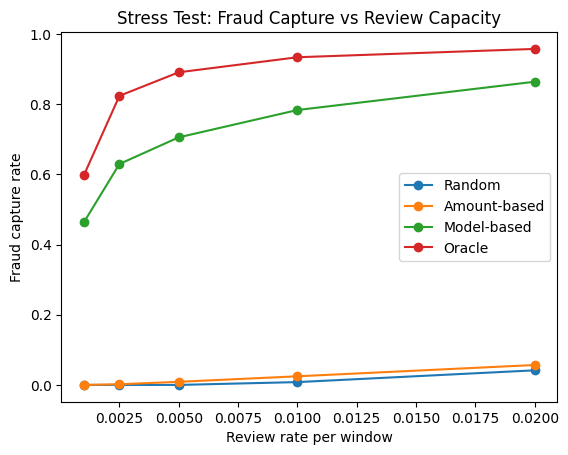

In [32]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(stress_capacity['review_rate'], stress_capacity['Random'], marker='o', label='Random')
plt.plot(stress_capacity['review_rate'], stress_capacity['Amount-based'], marker='o', label='Amount-based')
plt.plot(stress_capacity['review_rate'], stress_capacity['Model-based'], marker='o', label='Model-based')
plt.plot(stress_capacity['review_rate'], stress_capacity['Oracle'], marker='o', label='Oracle')

plt.xlabel('Review rate per window')
plt.ylabel('Fraud capture rate')
plt.title('Stress Test: Fraud Capture vs Review Capacity')
plt.legend()
plt.show()

8.3 Stress test B: Cost sensitivity

In [33]:
def policy_expected_cost_at_review_rate(df, review_rate, C_FN, C_FP, score_col=None):
    """
    Computes expected cost over all windows:
      - FP: reviewed & actually non-fraud
      - FN: not reviewed & actually fraud
    """
    total_fp = 0
    total_fn = 0

    for w, df_w in df.groupby('window_id'):
        n = len(df_w)
        K = max(1, int(n * review_rate))

        if score_col is None:
            reviewed_idx = np.random.choice(df_w.index, size=min(K, n), replace=False)
        else:
            df_sorted = df_w.sort_values(score_col, ascending=False)
            reviewed_idx = df_sorted.head(K).index

        reviewed = df_w.index.isin(reviewed_idx)

        fp = ((reviewed) & (df_w['Class'].values == 0)).sum()
        fn = ((~reviewed) & (df_w['Class'].values == 1)).sum()

        total_fp += fp
        total_fn += fn

    return C_FP * total_fp + C_FN * total_fn

In [34]:
np.random.seed(42)

cost_ratios = [10, 25, 50, 100, 200]  # C_FN / C_FP
review_rate = 0.005  # keep at 0.5% for this test

rows = []
for ratio in cost_ratios:
    C_FP = 1
    C_FN = ratio

    rows.append({
        'C_FN/C_FP': ratio,
        'Random': policy_expected_cost_at_review_rate(df, review_rate, C_FN, C_FP, score_col=None),
        'Amount-based': policy_expected_cost_at_review_rate(df, review_rate, C_FN, C_FP, score_col='Amount'),
        'Model-based': policy_expected_cost_at_review_rate(df, review_rate, C_FN, C_FP, score_col='risk_score'),
        'Oracle': policy_expected_cost_at_review_rate(df, review_rate, C_FN, C_FP, score_col='Class'),
    })

stress_cost = pd.DataFrame(rows)
stress_cost

,C_FN/C_FP,Random,Amount-based,Model-based,Oracle
0,10,6309,6265,2481,1678
1,25,13700,13570,4626,2728
2,50,26000,25745,8201,4478
3,100,50196,50095,15351,7978
4,200,99599,98795,29651,14978


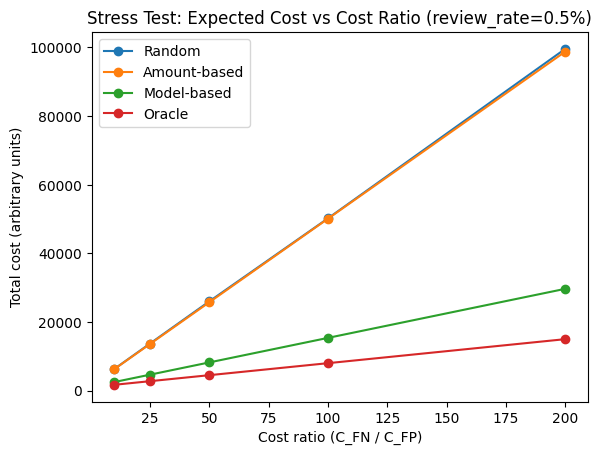

In [35]:
plt.figure()
plt.plot(stress_cost['C_FN/C_FP'], stress_cost['Random'], marker='o', label='Random')
plt.plot(stress_cost['C_FN/C_FP'], stress_cost['Amount-based'], marker='o', label='Amount-based')
plt.plot(stress_cost['C_FN/C_FP'], stress_cost['Model-based'], marker='o', label='Model-based')
plt.plot(stress_cost['C_FN/C_FP'], stress_cost['Oracle'], marker='o', label='Oracle')

plt.xlabel('Cost ratio (C_FN / C_FP)')
plt.ylabel('Total cost (arbitrary units)')
plt.title('Stress Test: Expected Cost vs Cost Ratio (review_rate=0.5%)')
plt.legend()
plt.show()

## 9. Conclusions and Limitations

### 9.1 Key Findings

This project studied fraud risk screening under a strict manual review capacity constraint. Rather than optimizing classification metrics, the analysis focused on decision quality: how many fraudulent transactions can be captured when only a small fraction of transactions can be reviewed.

The main findings are:

- Fraud is extremely rare (~0.17%), making naive review policies ineffective under limited capacity.
- Random and amount-based heuristics capture less than 1% of fraud even when review capacity increases.
- A probabilistic risk scoring model based on logistic regression captures approximately 70% of fraud while reviewing only 0.5% of transactions.
- This represents roughly 80% of the theoretical maximum achievable capture rate (oracle policy), indicating high efficiency under constraint.
- Stress testing shows that the model degrades gracefully as review capacity tightens and consistently outperforms heuristics across all tested operating regimes.
- Cost sensitivity analysis demonstrates that as the cost of missed fraud increases, the value of accurate risk ranking increases substantially.

Overall, the results show that probabilistic ranking—not heuristic rules—is essential for effective fraud screening when operational resources are scarce.

---

### 9.2 Decision-Oriented Perspective

A key contribution of this project is framing fraud detection as a constrained decision problem rather than a pure prediction task. Even a highly accurate model cannot recover all fraud if review capacity is limited. Conversely, a well-ranked probability model can achieve strong outcomes without requiring complex architectures or aggressive tuning.

This highlights that:
- Model quality must be evaluated in the context of downstream decisions.
- Capacity constraints, not model accuracy alone, determine achievable performance.
- Simple, well-calibrated models can be highly effective when embedded in the correct decision framework.

---

### 9.3 Limitations

This analysis has several limitations:

- Features are anonymized and static; no behavioral aggregation or temporal feature engineering is used.
- Fraud labels are assumed to be immediate and error-free, whereas real systems often face delayed or noisy feedback.
- The model is trained once and does not account for concept drift over time.
- Review capacity is assumed to be fixed per window, while real operations may use adaptive or queue-based review systems.

These limitations are deliberate trade-offs to maintain clarity and focus on decision mechanics rather than feature complexity.

---

### 9.4 Possible Extensions

Future extensions could include:

- Probability calibration analysis to distinguish ranking quality from absolute probability accuracy.
- Time-adaptive retraining to handle concept drift.
- Queue-based or multi-stage review policies.
- Integration of delayed labels and partial feedback.
- Comparison with more complex models under the same decision framework.

Any extension should preserve the decision-centric evaluation used in this project.

---

### 9.5 Final Remark

This project demonstrates that effective data science lies not in maximizing abstract metrics, but in aligning probabilistic modeling with operational constraints and business costs. Under realistic review limits, decision-aware risk ranking substantially outperforms heuristics and approaches the best achievable outcomes.
